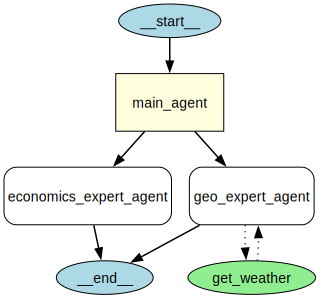

In [5]:
from agents.extensions.visualization import draw_graph
from pydantic import BaseModel
from dotenv import load_dotenv
from openai import AsyncOpenAI
from agents import Agent, Runner, function_tool, SQLiteSession, set_default_openai_client, set_tracing_disabled
import httpx

load_dotenv()

set_tracing_disabled(True)

set_default_openai_client(
    AsyncOpenAI(
        http_client=httpx.AsyncClient(verify=False) 
    )
)

session = SQLiteSession("user_1", "ai-memory.db")


class Answer(BaseModel):
    answer: str
    background_explanation: str


@function_tool
def get_weather():
    return "30"


geography_agent = Agent(
    name="geo_expert_agent",
    instructions="You are a expert in geography, you answer questions related to them.",
    handoff_description="Use this to answer geography related questions.",
    tools=[
        get_weather,
    ],
    output_type=Answer,
)
economics_agent = Agent(
    name="economics_expert_agent",
    instructions="You are a expert in economics, you answer questions related to them.",
    handoff_description="Use this to answer economics questions.",
)

main_agent = Agent(
    name="main_agent",
    instructions="You are a user facing agent. Transfer to the agent most capable of answering the user's question.",
    handoffs=[
        economics_agent,
        geography_agent,
    ],
)

draw_graph(main_agent)

In [6]:
result = await Runner.run(
    main_agent,
    "What is the capital of Thailand's northen province.",
    session=session,
)

print(result.last_agent.name)
print(result.final_output)

geo_expert_agent
answer='Chiang Mai is the main capital/city of northern Thailand, but if you mean an individual northern province, each province has its own capital. For example, Chiang Mai province’s capital is Chiang Mai.' background_explanation='The question is a bit ambiguous because Thailand’s northern region has multiple provinces, not one province. The most common intended answer is Chiang Mai, the largest and best-known city in northern Thailand.'
